# Crop Recommendation System
#### Life cycle of Machine Learning Project
- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model
### 1) Problem statement
- Inefficient crop selection, driven by a lack of accessible data, results in suboptimal yields and financial instability for farmers, a problem this project aims to solve with machine learning.
### 2) Data Collection
- Data source - https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset
- I searched for another 4 crops and added them to the main dataset.
- The data consists of 8 column and 2749 rows.


### 2.1 Import Data and Required Packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import the CSV Data as Pandas DataFrame
df = pd.read_csv("G:/Graduation Project/Crop_Recommendation_System/notebook/data/Crop_Recommendation.csv")

df.head()  # Show top 5 rows

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.shape  # Shape of the dataset

(2599, 8)

### 2.2 Dataset information
- N: Nitrogen
- P: Phosphorus
- K: Potassium
- Temperature: in degree
- Humidity
- ph: Acidity level
- Rainfall: in mm
- label: name of 26 crops

### 3. Data Checks to perform
- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [4]:
df.isna().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

**Insights:**
There is no missing values

### 3.2 Check Duplicates

In [5]:
df.duplicated().sum()

np.int64(7)

**Insights:**
There is duplication

In [6]:
# This finds all rows that have at least one duplicate somewhere in the data
duplicate_rows = df[df.duplicated(keep=False)]
print(duplicate_rows.sort_values(by=['N', 'P', 'K']))

        N   P   K  temperature  humidity   ph  rainfall  label
2408   68  51  55         18.4      80.0  5.4      90.1  wheat
2423   68  51  55         18.4      80.0  5.4      90.1  wheat
2418   81  57  36         17.1      82.0  5.1      92.8  wheat
2426   81  57  36         17.1      82.0  5.1      92.8  wheat
2422  111  54  36         18.6      81.0  5.5      70.1  wheat
2428  111  54  36         18.6      81.0  5.5      70.1  wheat
2405  118  58  38         17.3      80.0  5.1      70.5  wheat
2420  118  58  38         17.3      80.0  5.1      70.5  wheat
2416  119  48  48         22.8      83.0  5.9      87.1  wheat
2424  119  48  48         22.8      83.0  5.9      87.1  wheat
2425  119  48  48         22.8      83.0  5.9      87.1  wheat
2427  119  48  48         22.8      83.0  5.9      87.1  wheat


**Insights:**
As we can see they are the same, so we can delete them

In [7]:
original_shape = df.shape  # before deleting
df = df.drop_duplicates()

print(f"Original rows: {original_shape[0]}")
print(f"Rows after dropping duplicates: {df.shape[0]}")

Original rows: 2599
Rows after dropping duplicates: 2592


### 3.3 Check data types

In [8]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2592 entries, 0 to 2598
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2592 non-null   int64  
 1   P            2592 non-null   int64  
 2   K            2592 non-null   int64  
 3   temperature  2592 non-null   float64
 4   humidity     2592 non-null   float64
 5   ph           2592 non-null   float64
 6   rainfall     2592 non-null   float64
 7   label        2592 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 182.2+ KB


### 3.4 Checking the number of unique values of each column

In [9]:
df.nunique()

N               137
P               117
K               181
temperature    2363
humidity       2396
ph             2278
rainfall       2537
label            26
dtype: int64

### 3.5 Check statistics of data set

In [10]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000
mean,53.349151,53.182099,55.457948,24.773548,71.618833,6.475990,104.868932
std,36.645374,30.831923,53.775479,5.325729,20.862152,0.746411,52.425961
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,23.000000,31.000000,22.000000,21.446222,61.184026,6.000000,68.478345
50%,40.000000,51.000000,37.000000,24.914157,78.705124,6.442312,97.306290
75%,87.250000,67.000000,54.000000,28.030411,87.918990,6.912644,123.592008
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


### 3.6 Check correlations of data set

In [11]:
df.corr(numeric_only=True)

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.206741,0.004950,-0.066421,0.182042,0.021770,0.015089
P,-0.206741,1.000000,0.643452,-0.097944,-0.091052,-0.143995,-0.037572
K,0.004950,0.643452,1.000000,-0.236566,0.168607,-0.184966,-0.029062
temperature,-0.066421,-0.097944,-0.236566,1.000000,0.172607,-0.025119,-0.016056
humidity,0.182042,-0.091052,0.168607,0.172607,1.000000,-0.021675,0.113892
ph,0.021770,-0.143995,-0.184966,-0.025119,-0.021675,1.000000,-0.081259
rainfall,0.015089,-0.037572,-0.029062,-0.016056,0.113892,-0.081259,1.000000


### 3.7 Exploring Data

In [12]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [13]:
print(f"We have data for {df.label.unique().size} crops")

We have data for 26 crops


In [14]:
print(f"Categories in 'label' variable: {df['label'].unique()}")

Categories in 'label' variable: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee' 'potato' 'tomato' 'wheat' 'clover']


In [15]:
df.label.value_counts()

label
wheat          106
tomato         102
potato         101
chickpea       100
pigeonpeas     100
mothbeans      100
mungbean       100
kidneybeans    100
rice           100
maize          100
pomegranate    100
lentil         100
blackgram      100
banana         100
muskmelon      100
mango          100
grapes         100
watermelon     100
papaya         100
orange         100
apple          100
coconut        100
coffee         100
jute           100
cotton         100
clover          83
Name: count, dtype: int64

In [16]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 7 numerical features : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

We have 1 categorical features : ['label']


### 4. Exploring Data ( Visualization )
- Target Variable Analysis (Crop Distribution)
- Numerical Features Distribution
- Feature vs. Target Analysis (Crop Requirements)
- Correlation Analysis (Heatmap)

In [17]:
# Set the style for all plots
sns.set(style="whitegrid")

#### 4.1 Target Variable Analysis (Crop Distribution)

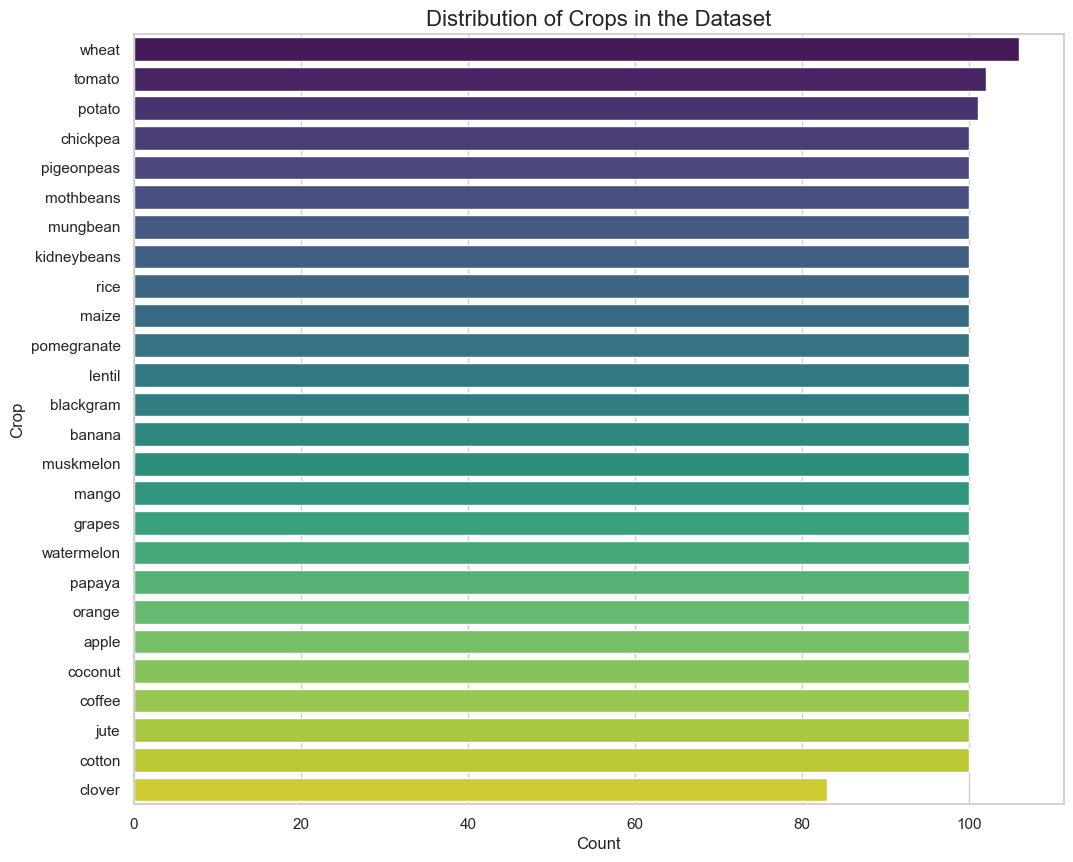

In [18]:
plt.figure(figsize=(12, 10))
sns.countplot(y='label', data=df, order = df['label'].value_counts().index, palette='viridis')
plt.title('Distribution of Crops in the Dataset', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Crop', fontsize=12)
plt.savefig('1_crop_distribution_plot.png')
plt.show()

**Insights**
- As the count plot illustrates, the dataset is well-balanced. Most crops have approximately 100 samples each. This balance is highly beneficial, as it prevents the machine learning model from developing a bias towards a specific majority class and ensures it can learn the distinct features of each crop effectively.

#### 4.2 Numerical Features Distribution

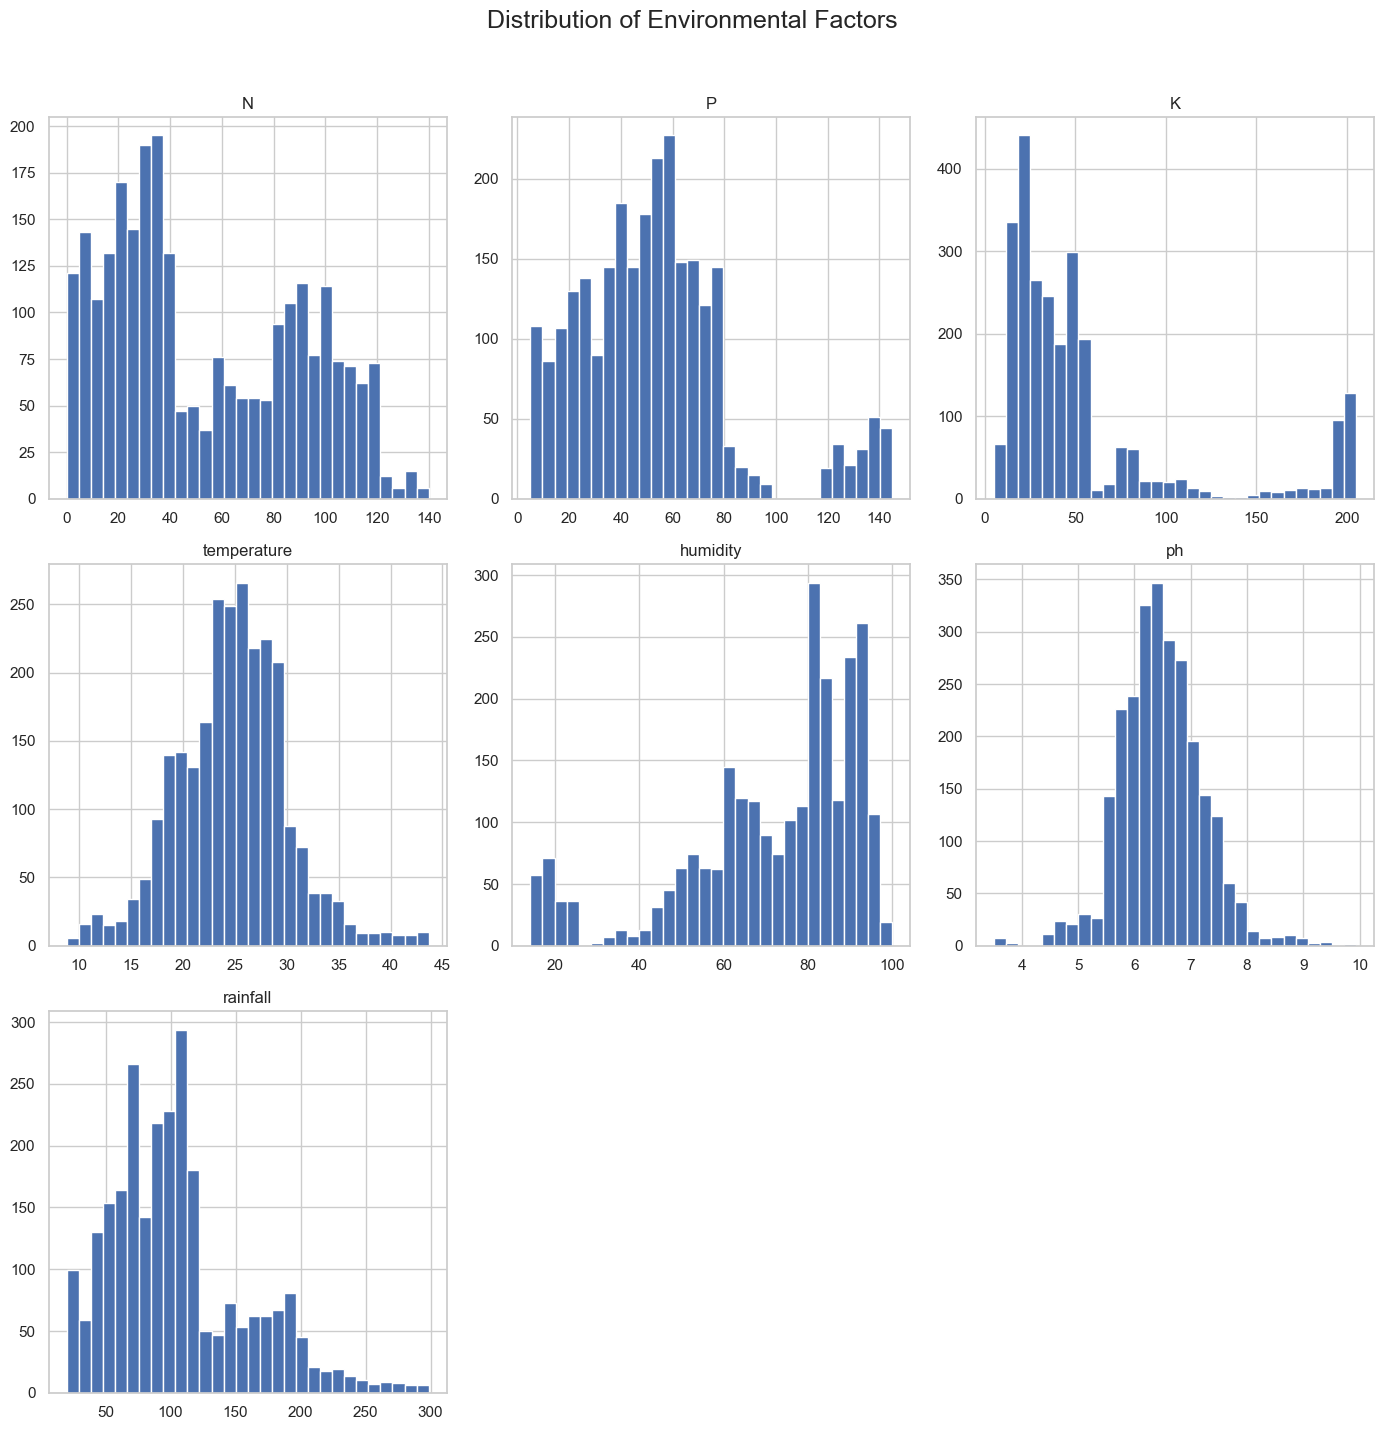

In [19]:
df.hist(figsize=(14, 14), bins=30, layout=(3, 3))
plt.suptitle('Distribution of Environmental Factors', y=1.02, fontsize=18)
plt.tight_layout()
plt.savefig('2_features_histograms.png')
plt.show()

**Insights:**
Histograms were generated for all 7 numerical features to understand their underlying distributions and statistical properties.

- Temperature & pH: Both 'temperature' and 'ph' follow a relatively normal (Gaussian) distribution. This indicates a good spread of data centered around the mean (approx. 20-30°C for temperature and 6.5 for pH).

- Humidity: The 'humidity' distribution is left-skewed, suggesting that a majority of the data points were recorded in high-humidity conditions.

- Rainfall: 'rainfall' is heavily right-skewed. This signifies that most recorded instances have low-to-moderate rainfall, with a few extreme outliers representing very heavy rainfall events.

- N, P, K (Soil Nutrients): These features show wide-ranging and multi-modal distributions, which is expected as the dataset covers diverse soil types suitable for 26 different crops.

#### 4.3 Feature vs. Target Analysis (Crop Requirements)

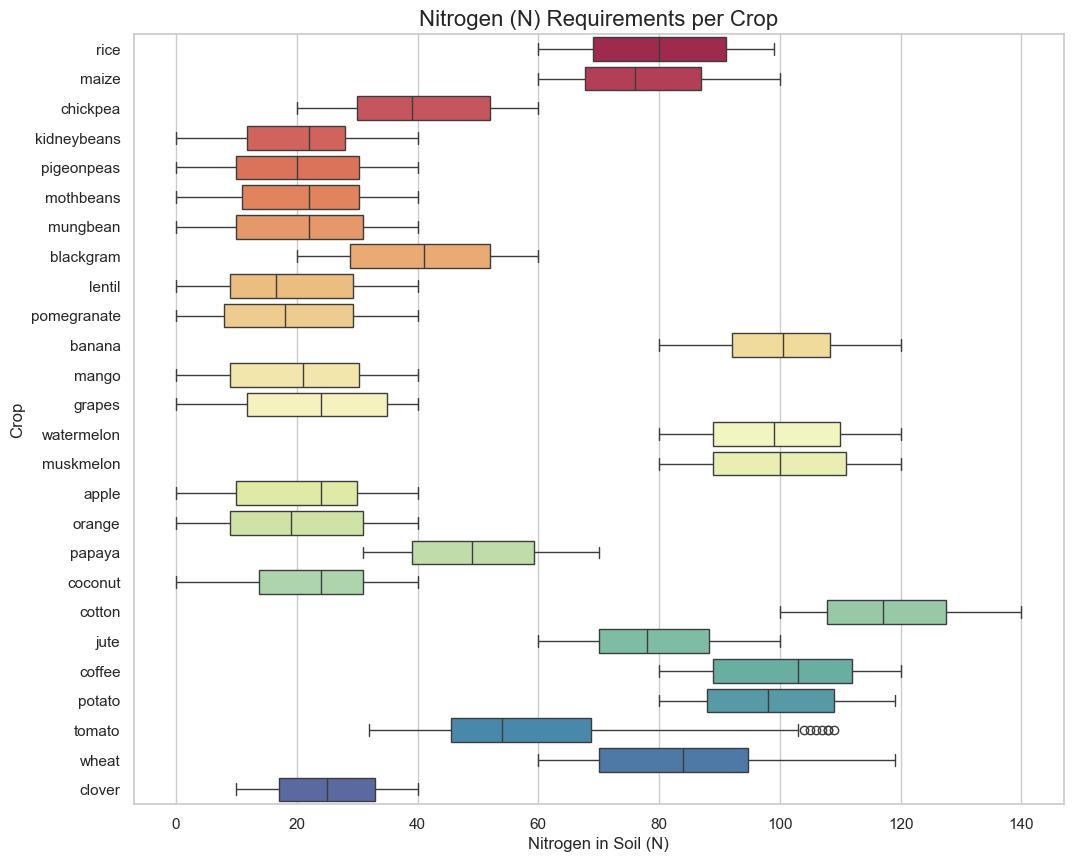

In [20]:
# Plotting Nitrogen (N) vs Crop
plt.figure(figsize=(12, 10))
sns.boxplot(y='label', x='N', data=df, palette='Spectral')
plt.title('Nitrogen (N) Requirements per Crop', fontsize=16)
plt.xlabel('Nitrogen in Soil (N)', fontsize=12)
plt.ylabel('Crop', fontsize=12)
plt.savefig('3.1_N_vs_crop_boxplot.png')
plt.show()

**Insights**
- Nitrogen (N) Requirements: The plot clearly distinguishes crop needs. For instance, 'rice' and 'cotton' consistently require very high 'N' values. In contrast, legumes like 'kidneybeans' and 'chickpea' thrive in low-N soil, (as they are nitrogen-fixing plants).

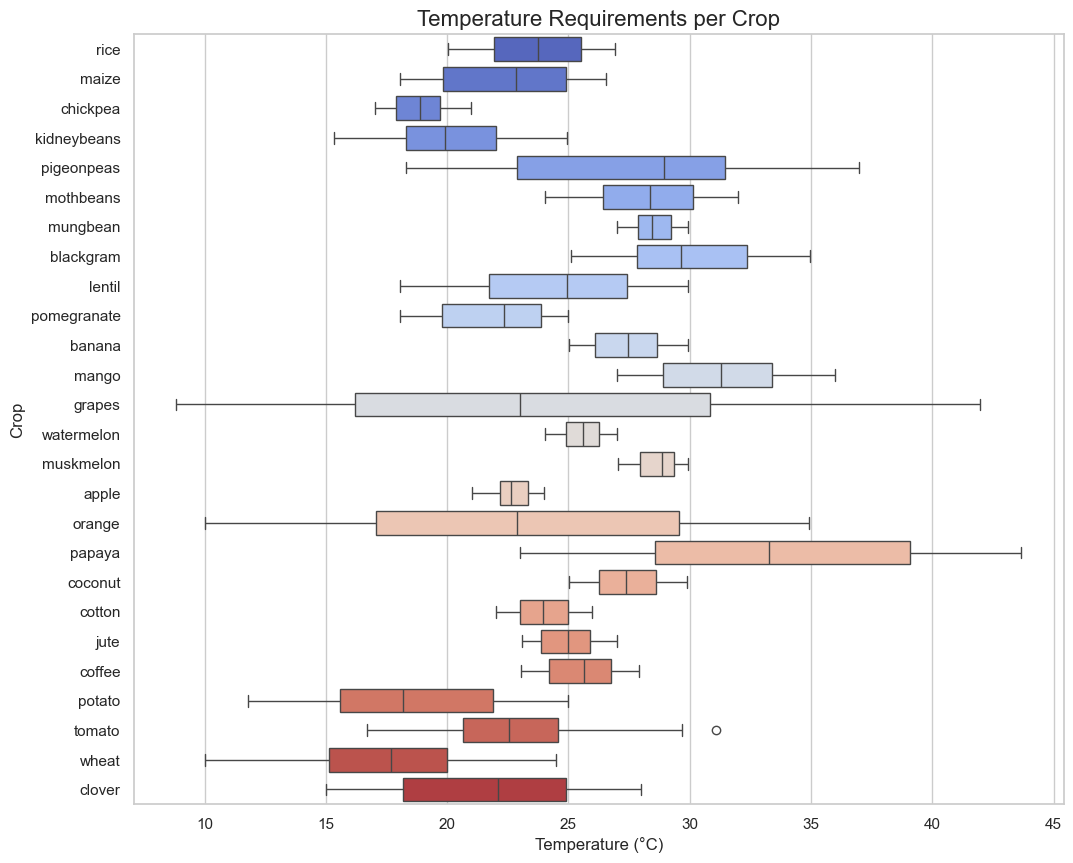

In [21]:
# Plotting Temperature vs Crop
plt.figure(figsize=(12, 10))
sns.boxplot(y='label', x='temperature', data=df, palette='coolwarm')
plt.title('Temperature Requirements per Crop', fontsize=16)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Crop', fontsize=12)
plt.savefig('3.2_temp_vs_crop_boxplot.png')
plt.show()

**Insights**
- Temperature Requirements: We observe distinct temperature preferences. 'coffee' and 'papaya' are associated with high-temperature climates, whereas 'potato' and 'wheat' prefer cooler, more moderate temperatures.

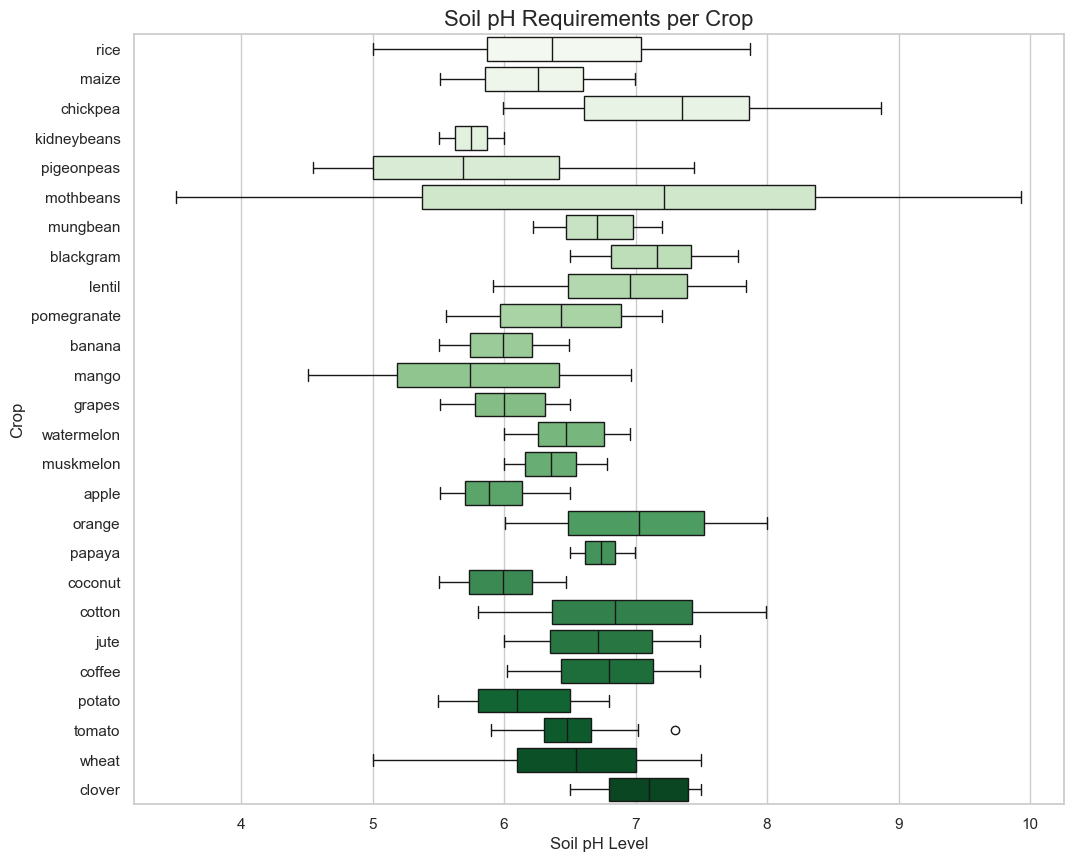

In [22]:
# Plotting pH vs Crop
plt.figure(figsize=(12, 10))
sns.boxplot(y='label', x='ph', data=df, palette='Greens')
plt.title('Soil pH Requirements per Crop', fontsize=16)
plt.xlabel('Soil pH Level', fontsize=12)
plt.ylabel('Crop', fontsize=12)
plt.savefig('3.3_ph_vs_crop_boxplot.png')
plt.show()

**Insights**
- pH Requirements: Most crops cluster around a neutral pH (6.0-7.0). However, 'rice' shows a tolerance for more acidic soil (lower pH), while 'clover' trends towards more alkaline conditions (higher pH).

#### 4.4 Correlation Analysis (Heatmap)

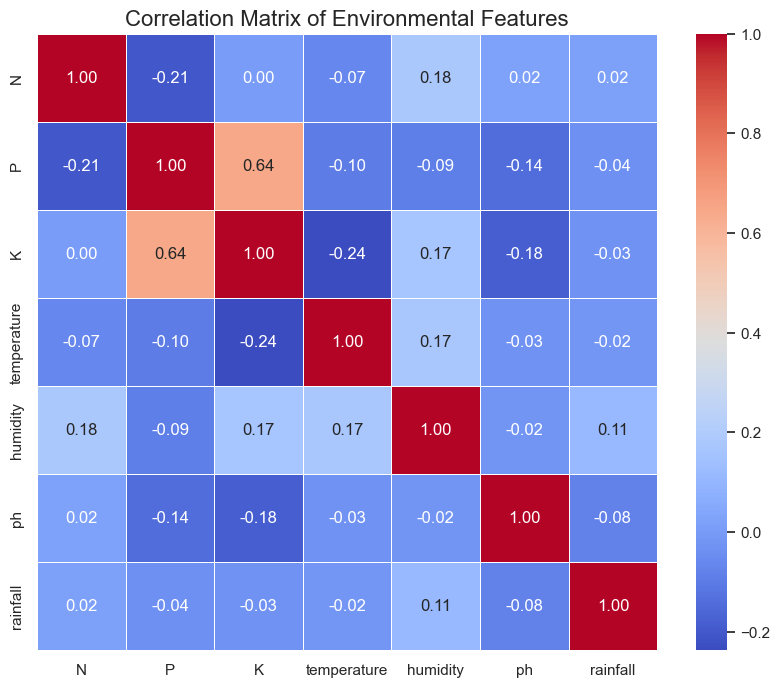

In [23]:
# Calculate the correlation matrix (drop non-numeric 'label' column)
corr_matrix = df.drop('label', axis=1).corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Environmental Features', fontsize=16)
plt.savefig('4_correlation_heatmap.png')
plt.show()

**Insights**
- The heatmap shows that all features have low-to-moderate correlation coefficients (values are far from 1.0 or -1.0). The highest observed correlation is a moderate positive relationship between 'K' (Potassium) and 'P' (Phosphorus) at 0.74, which is logical from an agricultural standpoint as these nutrients are often managed together.

# 5) EDA Conclusion & Next Steps

## Key Insights Summary

Based on the Exploratory Data Analysis, we have gathered the following critical insights:

1.  **Clean Data:** The dataset is clean with **no missing values** and **no duplicate rows**.
2.  **Balanced Target:** The dataset is **well-balanced**, containing 26 unique crops with approximately 100 samples each. This is ideal for training an unbiased model.
3.  **Predictive Features:** The box plots confirm that all 7 features (`N`, `P`, `K`, `temperature`, `humidity`, `ph`, `rainfall`) are highly predictive. Each crop has a distinct "signature" or optimal range for these features (e.g., high 'N' for rice, low 'N' for legumes), which is exactly what the model needs to learn.
4.  **No Multicollinearity:** The correlation heatmap shows **low-to-moderate correlation** between features. This indicates that all features provide independent information, and we can proceed with all of them for modeling.
5.  **Feature Distributions:** Features like 'rainfall' are right-skewed, while 'temperature' and 'ph' are normally distributed. This suggests that applying feature scaling might be beneficial for certain types of models.

## Next Steps

The EDA has confirmed that the data is ready for modeling. The subsequent steps in this project will be:

1.  **Data Pre-processing:**
    * **Label Encoding:** Convert the categorical `label` column (crop names) into numerical values that the model can understand (e.g., using `LabelEncoder`).
    * **Train-Test Split:** Split the dataset into features (X) and target (y), and then divide them into training and testing sets (e.g., 80% train, 20% test) using `train_test_split`.
    * **Feature Scaling:** Apply `StandardScaler` or `MinMaxScaler` to the numerical features (X) to normalize their range. This ensures that features with larger ranges (like 'rainfall') do not disproportionately influence the model's performance (especially for algorithms like KNN or SVM).

2.  **Model Training & Evaluation:**
    * We will train several classification algorithms on the prepared data, such as:
        * Logistic Regression
        * K-Nearest Neighbors (KNN)
        * Support Vector Machine (SVM)
        * Decision Tree
        * Random Forest
        * XGBoost
    * We will evaluate each model based on key metrics like **Accuracy**, **Precision**, **Recall**, and **F1-Score**, and analyze their **Confusion Matrix** to select the best-performing model for our recommendation system.